In [1]:
%pip install umap-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.compose import ColumnTransformer

In [3]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

In [4]:
df = pd.read_csv('german_credit_data.csv', index_col=0)
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,67,male,2,own,NaN,little,1169,6,radio/TV
1,22,female,2,own,little,moderate,5951,48,radio/TV
2,49,male,1,own,little,NaN,2096,12,education
3,45,male,2,free,little,little,7882,42,furniture/equipment
4,53,male,2,free,little,little,4870,24,car


In [5]:
# 1 EDA и Preprocessing
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Age               1000 non-null   int64
 1   Sex               1000 non-null   str  
 2   Job               1000 non-null   int64
 3   Housing           1000 non-null   str  
 4   Saving accounts   817 non-null    str  
 5   Checking account  606 non-null    str  
 6   Credit amount     1000 non-null   int64
 7   Duration          1000 non-null   int64
 8   Purpose           1000 non-null   str  
dtypes: int64(4), str(5)
memory usage: 70.4 KB


In [6]:
df.isnull().sum()

Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
dtype: int64

In [7]:
# заполнение пропусков и проверка
df['Saving accounts'] = df['Saving accounts'].fillna('unknown')
df['Checking account'] = df['Checking account'].fillna('unknown')
df.isnull().sum()

Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
dtype: int64

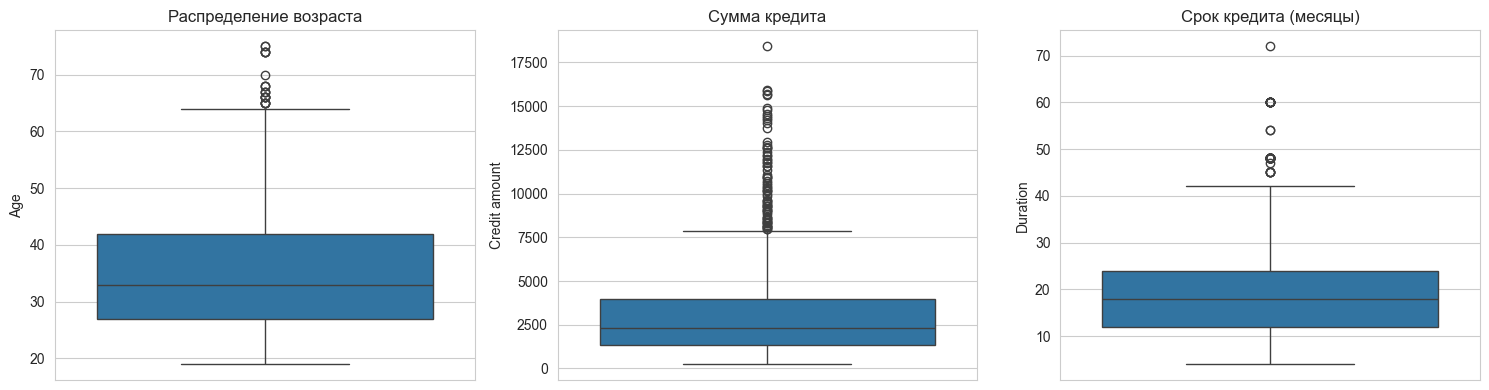

In [8]:
# распределение числовых признаков и выбросы
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(y=df['Age'], ax=axes[0])
axes[0].set_title('Распределение возраста')

sns.boxplot(y=df['Credit amount'], ax=axes[1])
axes[1].set_title('Сумма кредита')

sns.boxplot(y=df['Duration'], ax=axes[2])
axes[2].set_title('Срок кредита (месяцы)')

plt.tight_layout()
plt.show()

In [9]:
# Выводы:
# Age — в основном от 20 до 50 лет, есть выбросы старше 60
# Credit amount - широкий разброс, много выбросов
# Duration - в основном до 48 месяцев, есть выбросы до 72

In [10]:
# кодирование категориальных признаков
categorical_cols = ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=False)
df_encoded.head()

,Age,Job,Credit amount,Duration,Sex_female,Sex_male,Housing_free,Housing_own,Housing_rent,Saving accounts_little,...,Checking account_rich,Checking account_unknown,Purpose_business,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others
0,67,2,1169,6,False,True,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
1,22,2,5951,48,True,False,False,True,False,True,...,False,False,False,False,False,False,False,True,False,False
2,49,1,2096,12,False,True,False,True,False,True,...,False,True,False,False,False,True,False,False,False,False
3,45,2,7882,42,False,True,True,False,False,True,...,False,False,False,False,False,False,True,False,False,False
4,53,2,4870,24,False,True,True,False,False,True,...,False,False,False,True,False,False,False,False,False,False


In [11]:
# масштабирование
numeric_cols = ['Age', 'Credit amount', 'Duration']
scaler = StandardScaler()
df_scaled = df_encoded.copy()
df_scaled[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])
df_scaled[numeric_cols].describe()

,Age,Credit amount,Duration
count,1.000000e+03,1.000000e+03,1.000000e+03
mean,5.329071e-17,6.661338e-17,1.136868e-16
std,1.000500e+00,1.000500e+00,1.000500e+00
min,-1.455261e+00,-1.070865e+00,-1.402415e+00
25%,-7.516417e-01,-6.754833e-01,-7.386675e-01
50%,-2.239269e-01,-3.373443e-01,-2.408572e-01
75%,5.676451e-01,2.484620e-01,2.569531e-01
max,3.470076e+00,5.370789e+00,4.239436e+00


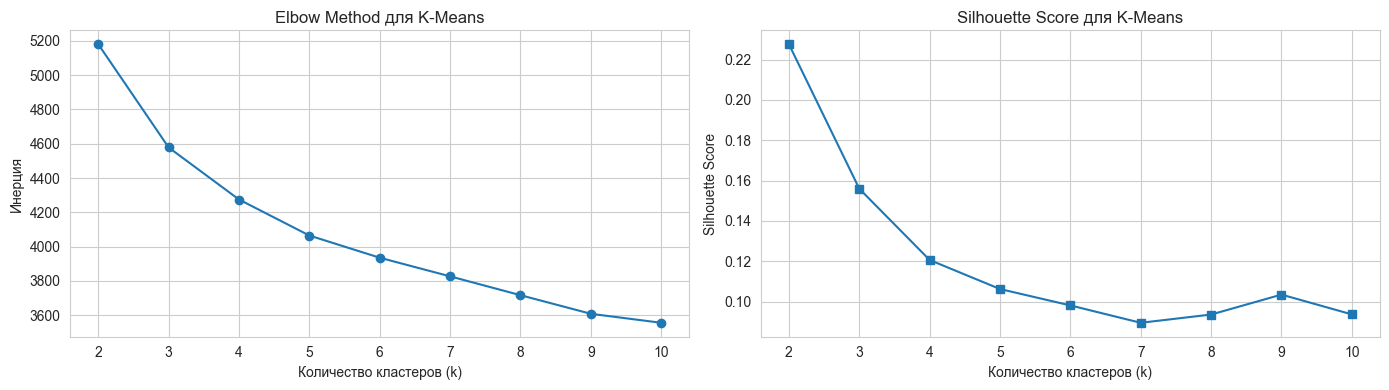

In [12]:
# Моделирование
# K-Means кластеризация
K_range = range(2, 11)
inertia = []
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_scaled, labels))

# Визуализируем
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Метод локтя (Elbow)
axes[0].plot(K_range, inertia, marker='o')
axes[0].set_title('Elbow Method для K-Means')
axes[0].set_xlabel('Количество кластеров (k)')
axes[0].set_ylabel('Инерция')

# Silhouette score
axes[1].plot(K_range, silhouette_scores, marker='s')
axes[1].set_title('Silhouette Score для K-Means')
axes[1].set_xlabel('Количество кластеров (k)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

In [13]:
k_optimal = 4
# Обучаем K-Means с оптимальным k
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(df_scaled)

df['KMeans_Cluster'] = kmeans_labels

In [14]:
print("Распределение по кластерам K-Means:")
print(df['KMeans_Cluster'].value_counts().sort_index())

Распределение по кластерам K-Means:
KMeans_Cluster
0    205
1    173
2    399
3    223
Name: count, dtype: int64


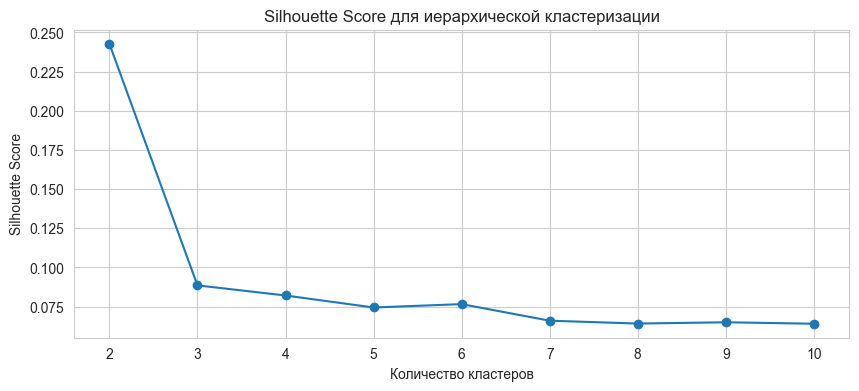

In [15]:
# иерархическая кластеризация -AgglomerativeClustering
silhouette_hier = []

for k in range(2, 11):
    hier = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = hier.fit_predict(df_scaled)
    silhouette_hier.append(silhouette_score(df_scaled, labels))

plt.figure(figsize=(10, 4))
plt.plot(range(2, 11), silhouette_hier, marker='o')
plt.title('Silhouette Score для иерархической кластеризации')
plt.xlabel('Количество кластеров')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

# Выбираем k=4
k_hier = 4
hier = AgglomerativeClustering(n_clusters=k_hier, linkage='ward')
hier_labels = hier.fit_predict(df_scaled)

df['Hier_Cluster'] = hier_labels

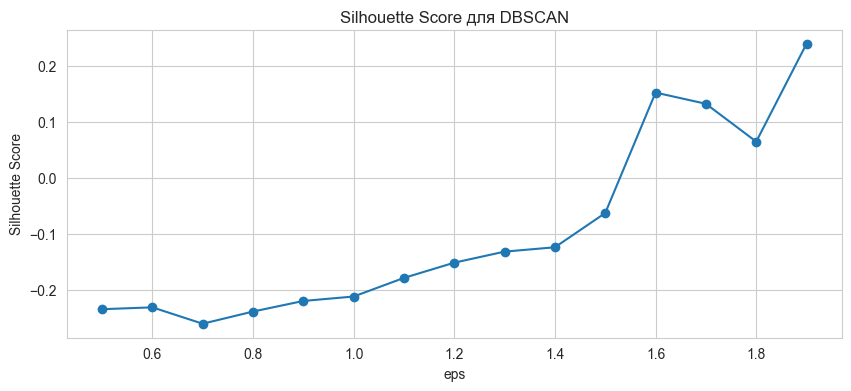

Уникальные кластеры DBSCAN: [np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21)]
Количество шума (кластер -1): 765


In [16]:
# dbscan
eps_values = np.arange(0.5, 2.0, 0.1)
silhouette_dbscan = []

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(df_scaled)
    if len(set(labels)) > 1:
        silhouette_dbscan.append(silhouette_score(df_scaled, labels))
    else:
        silhouette_dbscan.append(-1)

plt.figure(figsize=(10, 4))
plt.plot(eps_values, silhouette_dbscan, marker='o')
plt.title('Silhouette Score для DBSCAN')
plt.xlabel('eps')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

eps_best = 1.1
dbscan = DBSCAN(eps=eps_best, min_samples=5)
dbscan_labels = dbscan.fit_predict(df_scaled)

df['DBSCAN_Cluster'] = dbscan_labels

print("Уникальные кластеры DBSCAN:", sorted(set(dbscan_labels)))
print("Количество шума (кластер -1):", sum(dbscan_labels == -1))

In [17]:
# Снижаем размерность для визуализации
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_scaled)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(df_scaled)

umap_reducer = umap.UMAP(n_components=2, n_jobs=-1)  
X_umap = umap_reducer.fit_transform(df_scaled)

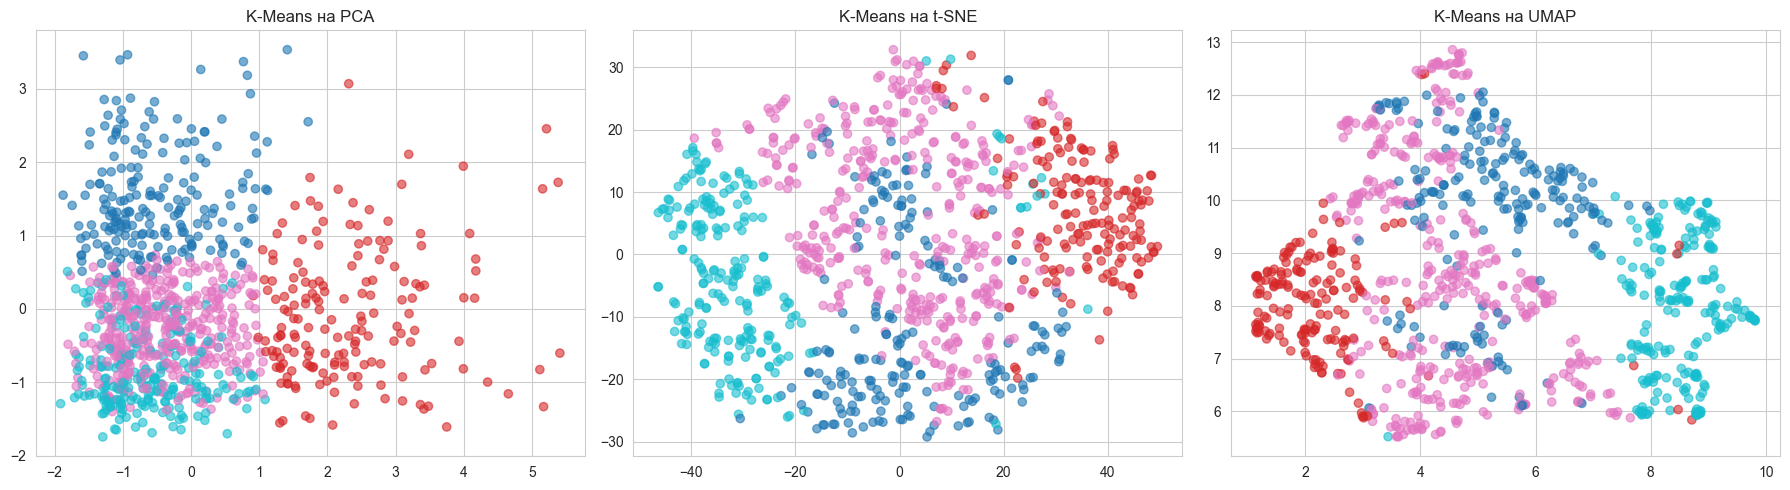

In [18]:
# K-Means
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='tab10', alpha=0.6)
axes[0].set_title('K-Means на PCA')

axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=kmeans_labels, cmap='tab10', alpha=0.6)
axes[1].set_title('K-Means на t-SNE')

axes[2].scatter(X_umap[:, 0], X_umap[:, 1], c=kmeans_labels, cmap='tab10', alpha=0.6)
axes[2].set_title('K-Means на UMAP')

plt.tight_layout()
plt.show()

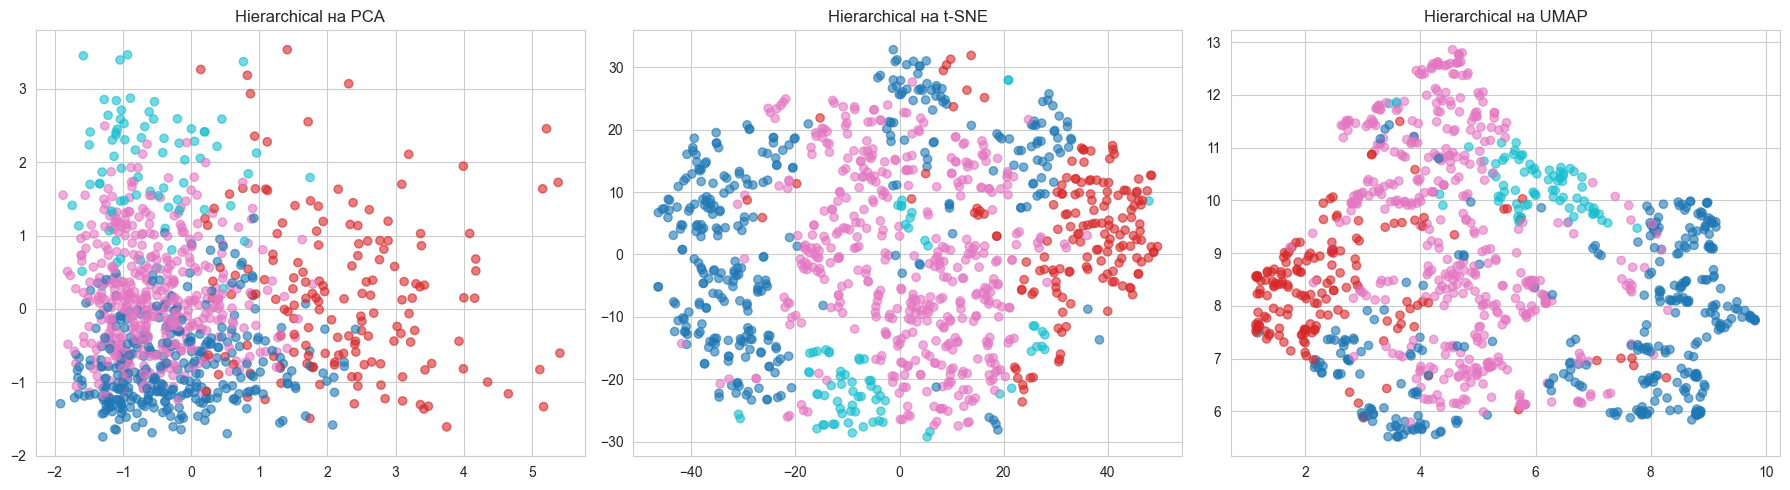

In [19]:
# Hierarchical
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=hier_labels, cmap='tab10', alpha=0.6)
axes[0].set_title('Hierarchical на PCA')

axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=hier_labels, cmap='tab10', alpha=0.6)
axes[1].set_title('Hierarchical на t-SNE')

axes[2].scatter(X_umap[:, 0], X_umap[:, 1], c=hier_labels, cmap='tab10', alpha=0.6)
axes[2].set_title('Hierarchical на UMAP')

plt.tight_layout()
plt.show()

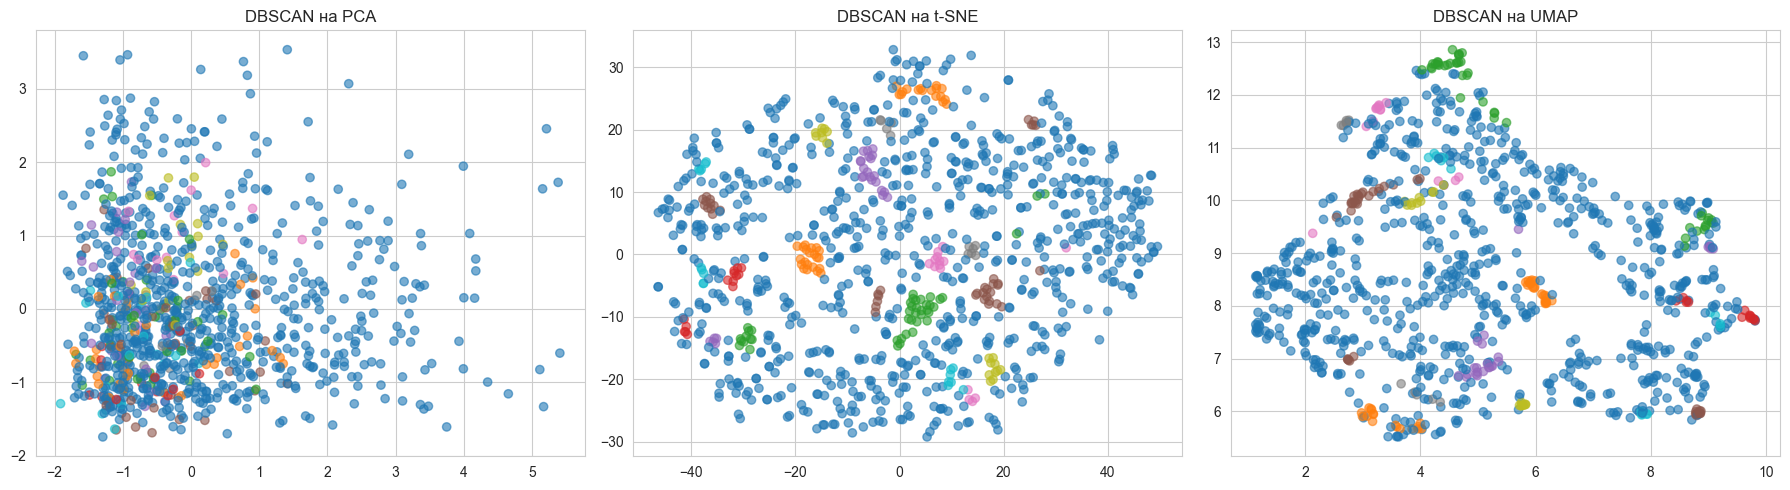

In [20]:
#  DBSCAN
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap='tab10', alpha=0.6)
axes[0].set_title('DBSCAN на PCA')

axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=dbscan_labels, cmap='tab10', alpha=0.6)
axes[1].set_title('DBSCAN на t-SNE')

axes[2].scatter(X_umap[:, 0], X_umap[:, 1], c=dbscan_labels, cmap='tab10', alpha=0.6)
axes[2].set_title('DBSCAN на UMAP')

plt.tight_layout()
plt.show()

In [21]:
# 3 Интерпретация кластеров
# Средние значения по кластерам (K-Means)

print("Колонки с кластерами:", [col for col in df.columns if 'Cluster' in col])

numeric_cols_orig = ['Age', 'Credit amount', 'Duration']

cluster_means = df.groupby('KMeans_Cluster')[numeric_cols_orig].mean()

print("Средние значения по кластерам:\n")
print(cluster_means.round(2))

Колонки с кластерами: ['KMeans_Cluster', 'Hier_Cluster', 'DBSCAN_Cluster']
Средние значения по кластерам:

                  Age  Credit amount  Duration
KMeans_Cluster                                
0               52.45        2318.08     15.93
1               35.31        7975.90     39.66
2               31.21        2358.62     17.65
3               27.94        2130.63     16.74


In [22]:
# Распределение категориальных признаков по кластерам

for cluster in sorted(df['KMeans_Cluster'].unique()):
    cluster_data = df[df['KMeans_Cluster'] == cluster]
    
    print(f"\nКластер {cluster}")
    print(f"Размер: {len(cluster_data)} клиентов ({len(cluster_data)/len(df)*100:.1f}%)")
    print(f"Средний возраст: {cluster_data['Age'].mean():.1f} лет")
    print(f"Средняя сумма кредита: {cluster_data['Credit amount'].mean():.0f} €")
    print(f"Средний срок кредита: {cluster_data['Duration'].mean():.0f} мес.")
    print(f"Пол: {cluster_data['Sex'].mode()[0]}")
    print(f"Жильё: {cluster_data['Housing'].mode()[0]}")
    print(f"Цель кредита: {cluster_data['Purpose'].mode()[0]}")


Кластер 0
Размер: 205 клиентов (20.5%)
Средний возраст: 52.4 лет
Средняя сумма кредита: 2318 €
Средний срок кредита: 16 мес.
Пол: male
Жильё: own
Цель кредита: car

Кластер 1
Размер: 173 клиентов (17.3%)
Средний возраст: 35.3 лет
Средняя сумма кредита: 7976 €
Средний срок кредита: 40 мес.
Пол: male
Жильё: own
Цель кредита: car

Кластер 2
Размер: 399 клиентов (39.9%)
Средний возраст: 31.2 лет
Средняя сумма кредита: 2359 €
Средний срок кредита: 18 мес.
Пол: male
Жильё: own
Цель кредита: radio/TV

Кластер 3
Размер: 223 клиентов (22.3%)
Средний возраст: 27.9 лет
Средняя сумма кредита: 2131 €
Средний срок кредита: 17 мес.
Пол: female
Жильё: own
Цель кредита: car


In [23]:
# Выводы:
for cluster in sorted(df['KMeans_Cluster'].unique()):
    cluster_data = df[df['KMeans_Cluster'] == cluster]
    size = len(cluster_data)
    avg_credit = cluster_data['Credit amount'].mean()
    avg_age = cluster_data['Age'].mean()
    
    if avg_credit < 5000 and avg_age < 35:
        print(f"Кластер {cluster}: Молодёжь, малые суммы → низкий риск")
    elif avg_credit > 10000 and avg_age < 35:
        print(f"Кластер {cluster}: Молодёжь, крупные суммы → высокий риск")
    elif avg_credit > 10000 and avg_age > 40:
        print(f"Кластер {cluster}: Взрослые, крупные суммы → средний риск")
    elif avg_credit < 8000 and avg_age > 45:
        print(f"Кластер {cluster}: Взрослые, малые суммы → низкий риск")
    else:
        print(f"Кластер {cluster}: Смешанный профиль → смотреть индивидуально")

Кластер 0: Взрослые, малые суммы → низкий риск
Кластер 1: Смешанный профиль → смотреть индивидуально
Кластер 2: Молодёжь, малые суммы → низкий риск
Кластер 3: Молодёжь, малые суммы → низкий риск


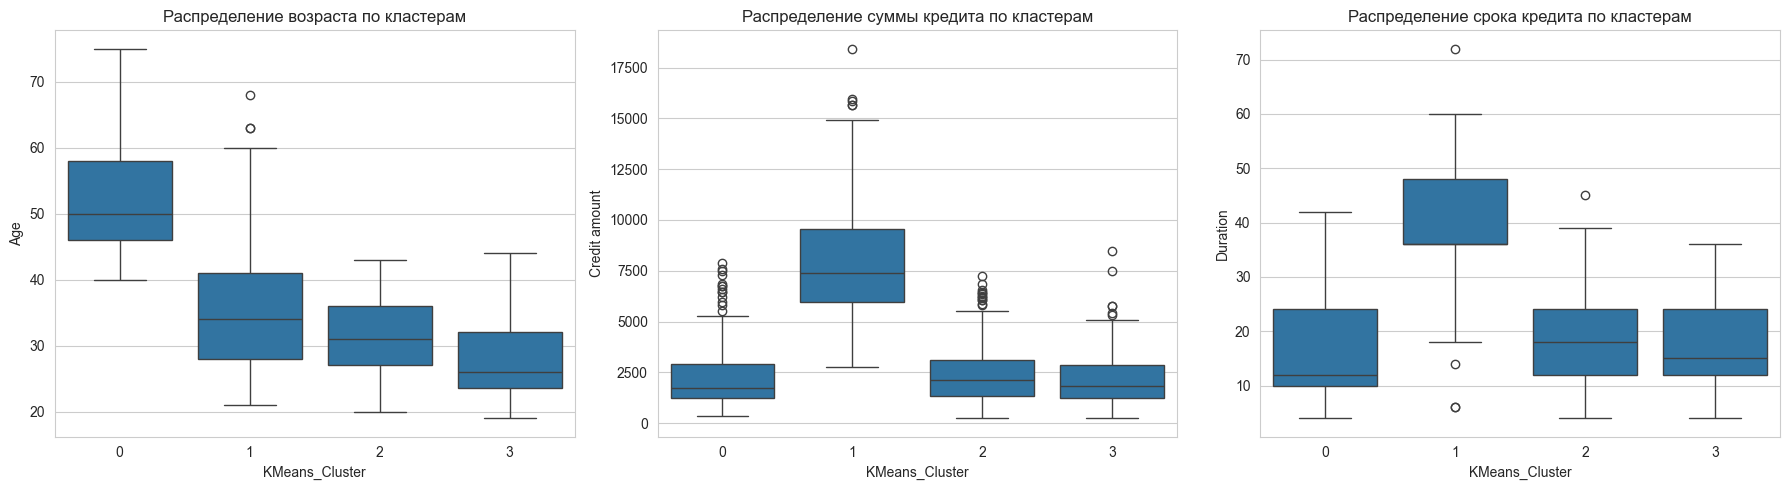

In [24]:
# Boxplot для числовых признаков 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(x='KMeans_Cluster', y='Age', data=df, ax=axes[0])
axes[0].set_title('Распределение возраста по кластерам')

sns.boxplot(x='KMeans_Cluster', y='Credit amount', data=df, ax=axes[1])
axes[1].set_title('Распределение суммы кредита по кластерам')

sns.boxplot(x='KMeans_Cluster', y='Duration', data=df, ax=axes[2])
axes[2].set_title('Распределение срока кредита по кластерам')

plt.tight_layout()
plt.show()

In [25]:
# Вывод:
# Сумма кредита - самый информативный признак: кластеры практически не пересекаются
# Срок кредита тоже хорошо разделяет кластеры
# Возраст имеет больше пересечений, но крайние кластеры отличаются сильно